# Week 1 — Introduction to Machine Learning

Combined notebook covering all Week 1 topics: Intro to ML, Supervised Learning,
Unsupervised Learning, Reinforcement Learning, Statistical Decision Theory
(Regression & Classification), and the Bias-Variance Tradeoff.

Each section has a brief description followed by a small runnable demo that
illustrates the concept.


---
## 1. Introduction to Machine Learning

ML is about learning a function from **data** rather than hand-coding rules.
Below: a "rule-based" approach vs a "learned" approach for the same simple
problem (classifying points as above/below a line), showing how a learned
model can generalize even when we don't know the exact rule in advance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# True (unknown to the "learner") rule: label = 1 if y > 2x + 1 else 0
X = np.random.uniform(-5, 5, (200, 2))
y = (X[:, 1] > 2 * X[:, 0] + 1).astype(int)

# Rule-based approach: we hard-code the exact boundary (only possible because we peeked)
def rule_based(x):
    return (x[:, 1] > 2 * x[:, 0] + 1).astype(int)

# Learned approach: model discovers the boundary from data alone
model = LogisticRegression()
model.fit(X, y)

print("Rule-based accuracy (cheating, knows the true rule):", (rule_based(X) == y).mean())
print("Learned model accuracy (only saw data + labels):", model.score(X, y))
print("Learned coefficients (should approximate slope=2, intercept=1 boundary):",
      model.coef_, model.intercept_)

Rule-based accuracy (cheating, knows the true rule): 1.0
Learned model accuracy (only saw data + labels): 1.0
Learned coefficients (should approximate slope=2, intercept=1 boundary): [[-2.8909117   1.46735125]] [-1.43078304]


---
## 2. Supervised Learning

Learning a mapping from inputs `X` to **known** outputs `y`. Two flavors:
**Regression** (continuous target) and **Classification** (discrete target).
Below: one quick example of each on toy data.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

np.random.seed(42)

# --- Regression example ---
X_reg = np.random.uniform(0, 10, (100, 1))
y_reg = 3 * X_reg.flatten() + 5 + np.random.normal(0, 2, 100)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg = LinearRegression().fit(Xr_tr, yr_tr)
print("Regression MSE:", mean_squared_error(yr_te, reg.predict(Xr_te)))

# --- Classification example ---
X_clf = np.random.uniform(-3, 3, (100, 2))
y_clf = (X_clf[:, 0] + X_clf[:, 1] > 0).astype(int)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(max_depth=3).fit(Xc_tr, yc_tr)
print("Classification accuracy:", accuracy_score(yc_te, clf.predict(Xc_te)))

Regression MSE: 2.6147980548680105
Classification accuracy: 0.95


---
## 3. Unsupervised Learning

No labels — the goal is to find **structure** in the data itself. Below:
K-Means clustering discovers 3 natural groups in unlabeled 2D data, and PCA
reduces dimensionality while preserving most of the variance.


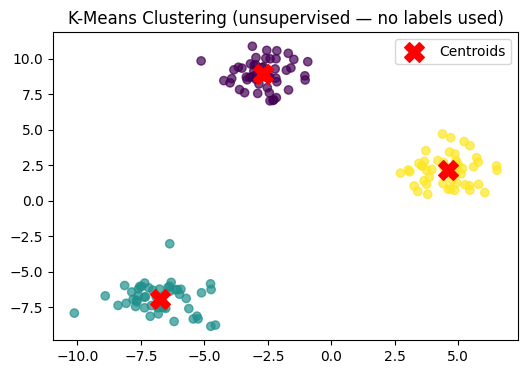

Explained variance ratio (first 2 components): [0.15274725 0.14226527]


In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

X_blobs, true_labels = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_blobs)

plt.figure(figsize=(6, 4))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroids")
plt.title("K-Means Clustering (unsupervised — no labels used)")
plt.legend()
plt.show()

# PCA on higher-dimensional data
X_high = np.random.normal(size=(100, 10))
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_high)
print("Explained variance ratio (first 2 components):", pca.explained_variance_ratio_)

---
## 4. Reinforcement Learning

An agent learns a **policy** by interacting with an environment and receiving
rewards/penalties — no labeled dataset, just trial and error. Below: a
minimal **multi-armed bandit** example using an epsilon-greedy strategy,
learning which of 3 "arms" gives the highest average reward.


In [4]:
np.random.seed(42)

true_reward_probs = [0.3, 0.5, 0.8]   # unknown to the agent in advance
n_arms = len(true_reward_probs)
n_steps = 1000
epsilon = 0.1

Q = np.zeros(n_arms)          # estimated value of each arm
counts = np.zeros(n_arms)     # number of times each arm was pulled
rewards_history = []

for step in range(n_steps):
    if np.random.rand() < epsilon:
        arm = np.random.randint(n_arms)     # explore
    else:
        arm = np.argmax(Q)                  # exploit best-known arm

    reward = 1 if np.random.rand() < true_reward_probs[arm] else 0
    counts[arm] += 1
    Q[arm] += (reward - Q[arm]) / counts[arm]   # incremental average update
    rewards_history.append(reward)

print("True reward probabilities:", true_reward_probs)
print("Learned Q-values:         ", np.round(Q, 3))
print("Times each arm was pulled:", counts.astype(int))
print("Average reward over last 100 steps:", np.mean(rewards_history[-100:]))

True reward probabilities: [0.3, 0.5, 0.8]
Learned Q-values:          [0.312 0.561 0.802]
Times each arm was pulled: [ 48  41 911]
Average reward over last 100 steps: 0.78


---
## 5. Statistical Decision Theory — Regression

For continuous targets, minimizing **expected squared error**
$E[(Y - f(X))^2]$ is provably minimized by $f(x) = E[Y \mid X = x]$ — the
conditional mean. Below: we simulate data, compute the true conditional mean
at a point, and confirm it's the value that minimizes squared error better
than any other constant prediction.


True conditional mean E[Y|X=x]: 7.0
Prediction that empirically minimizes squared error: 7.071


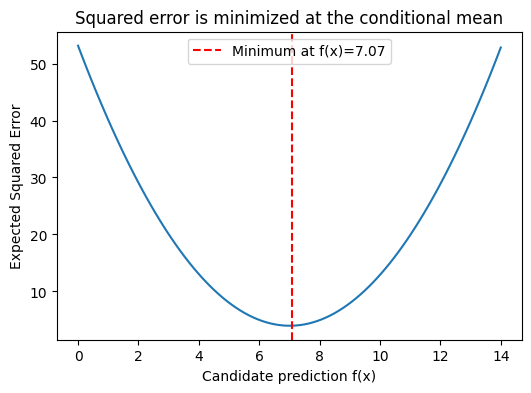

In [5]:
np.random.seed(42)

# For a fixed x, Y is drawn from a noisy distribution around a true mean
true_mean_at_x = 7.0
Y_samples = true_mean_at_x + np.random.normal(0, 2, 5000)

candidate_predictions = np.linspace(0, 14, 100)
expected_sq_errors = [np.mean((Y_samples - c) ** 2) for c in candidate_predictions]

best_c = candidate_predictions[np.argmin(expected_sq_errors)]
print(f"True conditional mean E[Y|X=x]: {true_mean_at_x}")
print(f"Prediction that empirically minimizes squared error: {best_c:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(candidate_predictions, expected_sq_errors)
plt.axvline(best_c, color="red", linestyle="--", label=f"Minimum at f(x)={best_c:.2f}")
plt.xlabel("Candidate prediction f(x)")
plt.ylabel("Expected Squared Error")
plt.title("Squared error is minimized at the conditional mean")
plt.legend()
plt.show()

---
## 6. Statistical Decision Theory — Classification

For discrete labels, minimizing expected misclassification error leads to the
**Bayes classifier**: predict the class with the highest posterior probability
$P(Y=k \mid X=x)$. Below: given known class-conditional distributions, we
show that classifying by "most probable class" minimizes total error compared
to other threshold choices.


Empirically best threshold: 4.030
Theoretical Bayes decision boundary (midpoint, equal variance/prior): 4.000


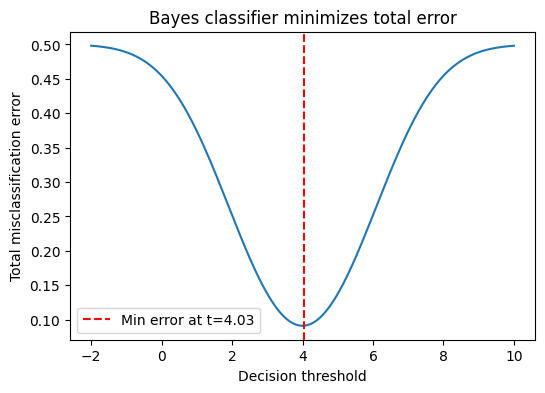

In [6]:
from scipy.stats import norm

# Two classes with known distributions (in practice these are estimated from data)
mean0, mean1 = 2, 6
std0, std1 = 1.5, 1.5
prior0, prior1 = 0.5, 0.5

thresholds = np.linspace(-2, 10, 200)
error_rates = []

for t in thresholds:
    # Predict class 1 if x > t, else class 0
    # Error = P(X>t | class0)*prior0 + P(X<=t | class1)*prior1
    err = (1 - norm.cdf(t, mean0, std0)) * prior0 + norm.cdf(t, mean1, std1) * prior1
    error_rates.append(err)

best_t = thresholds[np.argmin(error_rates)]
bayes_boundary = (mean0 + mean1) / 2  # equal variance/prior -> midpoint

print(f"Empirically best threshold: {best_t:.3f}")
print(f"Theoretical Bayes decision boundary (midpoint, equal variance/prior): {bayes_boundary:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, error_rates)
plt.axvline(best_t, color="red", linestyle="--", label=f"Min error at t={best_t:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Total misclassification error")
plt.title("Bayes classifier minimizes total error")
plt.legend()
plt.show()

---
## 7. Bias-Variance Tradeoff

Total expected test error decomposes as:
$$
\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

Below: fitting polynomials of increasing degree to noisy data shows the
tradeoff directly — low-degree models **underfit** (high bias), very
high-degree models **overfit** (high variance), and there's a sweet spot
in between.


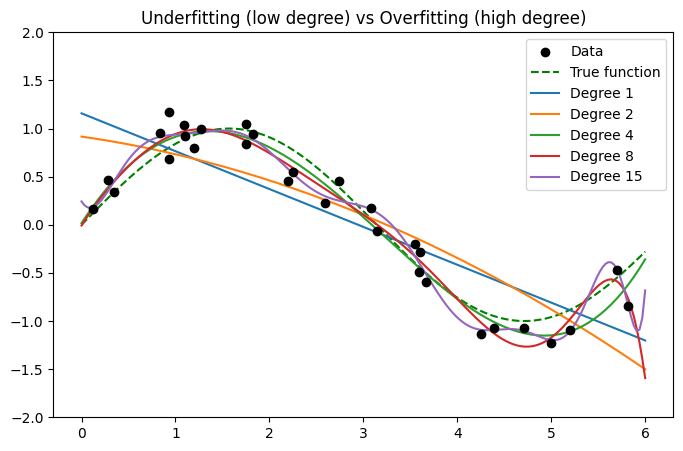

Cross-validated MSE per polynomial degree:
  Degree 1: CV-MSE = 0.2065
  Degree 2: CV-MSE = 0.2105
  Degree 4: CV-MSE = 0.0445
  Degree 8: CV-MSE = 0.0497
  Degree 15: CV-MSE = 90.2439

Lowest-degree models underfit (high bias), highest-degree models overfit (high variance).
The best CV-MSE marks the sweet spot in the tradeoff.


In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

np.random.seed(42)

def true_function(x):
    return np.sin(x)

X_bv = np.random.uniform(0, 6, 30).reshape(-1, 1)
y_bv = true_function(X_bv.flatten()) + np.random.normal(0, 0.2, 30)

degrees = [1, 2, 4, 8, 15]
x_plot = np.linspace(0, 6, 200).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_bv, y_bv, color="black", label="Data", zorder=5)
plt.plot(x_plot, true_function(x_plot.flatten()), color="green", linestyle="--", label="True function")

cv_errors = []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_bv, y_bv)
    plt.plot(x_plot, model.predict(x_plot), label=f"Degree {d}")

    scores = cross_val_score(model, X_bv, y_bv, cv=5, scoring="neg_mean_squared_error")
    cv_errors.append(-scores.mean())

plt.ylim(-2, 2)
plt.legend()
plt.title("Underfitting (low degree) vs Overfitting (high degree)")
plt.show()

print("Cross-validated MSE per polynomial degree:")
for d, err in zip(degrees, cv_errors):
    print(f"  Degree {d}: CV-MSE = {err:.4f}")
print("\nLowest-degree models underfit (high bias), highest-degree models overfit (high variance).")
print("The best CV-MSE marks the sweet spot in the tradeoff.")

---
## Summary

- **Intro to ML** — learn functions from data instead of hand-coded rules
- **Supervised Learning** — learn from labeled data (regression/classification)
- **Unsupervised Learning** — find structure with no labels (clustering, PCA)
- **Reinforcement Learning** — learn a policy from rewards via trial and error
- **Decision Theory (Regression)** — optimal predictor = conditional mean $E[Y|X]$
- **Decision Theory (Classification)** — optimal predictor = Bayes classifier (most probable class)
- **Bias-Variance Tradeoff** — total error = Bias² + Variance + Irreducible Error; model
  complexity must be tuned to balance the two

**Key takeaway:** ML is about picking a function that predicts well on *new*
data, not just data it's already seen. Statistical decision theory gives the
formal way to define "predicts well," and bias-variance explains why getting
that right is a balancing act, not a one-shot fix.
